# 03 · §7.3 Descriptor & Objective (H3, H4)

**H3:** profile-vs-MDS accuracy crossed with the offline fidelity/stability probe (`descriptor_probe.csv`) — recommend a descriptor only where the accuracy gap clears noise **and** is explained by a measured mechanism. **H4:** regression-vs-contrastive λg-robustness overlay + band width.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # RKD/ on path
sys.path.insert(0, os.getcwd())
import analysis_utils as au
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
df = pd.read_csv('results.csv')

### H3 — descriptor fidelity/stability probe (runs now, no training)
MDS near-degeneracy and profile tie rate vs N; this is the *mechanism* evidence the paper's §7.3 asks to cross with accuracy.

,N,norm,method,descriptor_dim,collision_rate,n_distinct_pairs,mds_degenerate_rate,profile_tie_rate
0,3,per_graph,profile,6,0.0021,39492,NaN,0.0342
1,3,per_graph,mds,3,0.0259,39492,0.0013,NaN
2,3,minibatch,profile,6,0.0000,39492,NaN,0.0342
3,3,minibatch,mds,3,0.0008,39492,0.0013,NaN
4,3,none,profile,6,0.0000,39492,NaN,0.0342
5,3,none,mds,3,0.0008,39492,0.0013,NaN
6,3,hybrid,profile,6,0.0000,39492,NaN,0.0342
7,3,hybrid,mds,3,0.0005,39492,0.0013,NaN
8,4,per_graph,profile,12,0.0000,39915,NaN,0.0553
9,4,per_graph,mds,4,0.0015,39915,0.0067,NaN


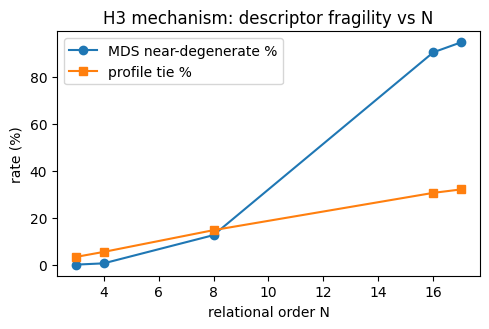

In [3]:
probe = au.load_probe(); display(probe)
au.fig_probe();

### H3 — profile vs MDS accuracy by (N, dataset, teacher) [needs runs]

In [4]:
g3 = df[(df.phase=='phase3')&(df.student=='graph-rkd')]
if len(g3):
    display(au.agg(g3,['dataset','teacher','method','N'],'test_mAP@R'))
else:
    print('no phase3 runs yet — the probe above already gives the mechanism (H3)')

,dataset,teacher,method,N,median,mean,sem,n
0,cars196,convnext_tiny,mds,3.0000,0.0135,0.0108,0.0040,3
1,cars196,convnext_tiny,mds,4.0000,0.0113,0.0103,0.0043,3
2,cars196,convnext_tiny,mds,8.0000,0.0093,0.0087,0.0036,3
3,cars196,convnext_tiny,profile,3.0000,0.0114,0.0096,0.0039,3
4,cars196,convnext_tiny,profile,4.0000,0.0089,0.0090,0.0035,3
5,cars196,convnext_tiny,profile,8.0000,0.0081,0.0088,0.0031,3
6,cars196,resnet18,mds,3.0000,0.0130,0.0108,0.0041,3
7,cars196,resnet18,mds,4.0000,0.0108,0.0097,0.0038,3
8,cars196,resnet18,mds,8.0000,0.0091,0.0090,0.0039,3
9,cars196,resnet18,profile,3.0000,0.0107,0.0099,0.0043,3


### H4 — objective robustness overlay (phase4)

largura da banda λg (dentro de 1 sem do melhor) por objetivo:
  contrastive: (0.01, 0.01)
  regression: (0.01, 0.01)


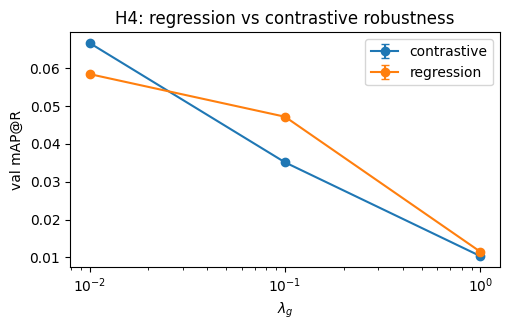

In [5]:
fig, widths = au.fig_h4_overlay(df)
print('largura da banda λg (dentro de 1 sem do melhor) por objetivo:')
for k,v in (widths or {}).items(): print(f'  {k}: {v}')